# Fiber Identification and Tracing Tutorial

This notebook demonstrates how to use the `amasedrp` fiber identification and tracing pipeline.

We will:
1. Generate a synthetic fiber-flat image
2. Identify fiber blocks and individual fibers
3. Trace each fiber along the dispersion direction
4. Fit a polynomial model to each trace
5. Visualize the results

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from amasedrp.reduction.core.fibermap import FiberMap
from amasedrp.reduction.core.fiberidentifier import FibersIdentifier
from amasedrp.reduction.core.tracemask import TraceMask

## 1. Generate a Synthetic Fiber-Flat Image

For this tutorial, we create a synthetic image with 3 blocks of 5 fibers each.
In practice, you would load a real fiber-flat frame from your instrument.

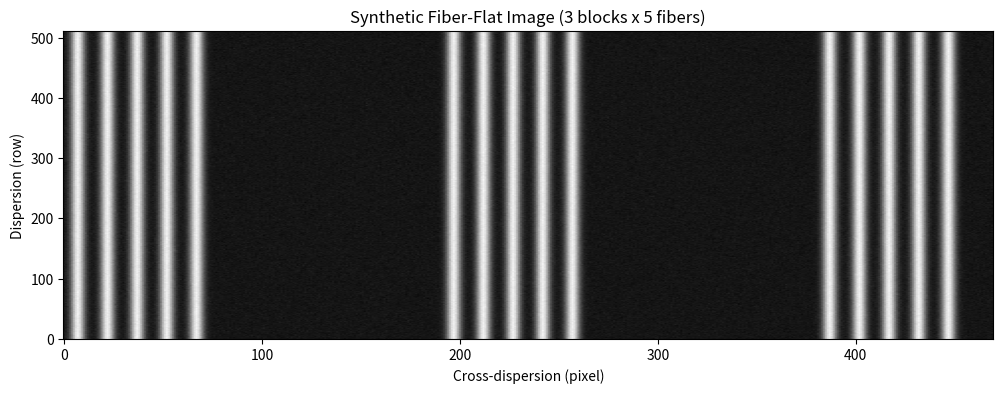

In [2]:
def synthetic_fiber_flat(
    n_rows=512,
    n_blocks=3,
    n_fibers_per_block=5,
    block_gap=100,
    fiber_spacing=15,
    fiber_sigma=2.5,
    noise_std=0.02,
): 
    """Generate a synthetic fiber-flat image."""
    fiber_profile_width = int(6 * fiber_sigma)
    block_width = n_fibers_per_block * fiber_spacing + fiber_profile_width
    n_cols = n_blocks * block_width + (n_blocks - 1) * block_gap
    
    image = np.zeros((n_rows, n_cols), dtype=np.float64)
    x = np.arange(n_cols)
    col_offset = fiber_profile_width // 2
    fiber_centers = []
    
    for b in range(n_blocks):
        for f in range(n_fibers_per_block):
            center = col_offset + f * fiber_spacing
            fiber_centers.append(float(center))
            profile = np.exp(-0.5 * ((x - center) / fiber_sigma) ** 2)
            image += profile[np.newaxis, :]
        col_offset += block_width + block_gap
    
    image += np.random.default_rng(42).normal(0, noise_std, image.shape)
    return image, fiber_centers

image, true_centers = synthetic_fiber_flat()

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(image, aspect='auto', origin='lower', cmap='gray')
ax.set_xlabel('Cross-dispersion (pixel)')
ax.set_ylabel('Dispersion (row)')
ax.set_title('Synthetic Fiber-Flat Image (3 blocks x 5 fibers)')
plt.show()

## 2. Identify Fiber Blocks and Individual Fibers

`FibersIdentifier` extracts a cross-dispersion profile, detects blocks via threshold crossing,
and finds individual fiber peaks within each block.

In [3]:
identifier = FibersIdentifier(
    image=image,
    n_blocks_expected=3,
    n_fibers_per_block_expected=5,
)

fibermap = identifier.identify(
    center_row=256,
    band_half_width=50,
)

print(f"Detected {fibermap.n_fibers} fibers in {len(np.unique(fibermap['BLOCKID']))} blocks")
print(f"\nFirst 5 rows of FiberMap:")
print(fibermap[:5])

Detected 15 fibers in 3 blocks

First 5 rows of FiberMap:
FIBERID BLOCKID BLOCK_LOCAL_ID APPROX_X CENTER_ROW VALID
------- ------- -------------- -------- ---------- -----
      0       0              0      7.0        256  True
      1       0              1     22.0        256  True
      2       0              2     37.0        256  True
      3       0              3     52.0        256  True
      4       0              4     67.0        256  True


In [4]:
fibermap

FIBERID,BLOCKID,BLOCK_LOCAL_ID,APPROX_X,CENTER_ROW,VALID
int64,int64,int64,float64,int64,bool
0,0,0,7.0,256,True
1,0,1,22.0,256,True
2,0,2,37.0,256,True
3,0,3,52.0,256,True
4,0,4,67.0,256,True
5,1,0,197.0,256,True
6,1,1,212.0,256,True
7,1,2,227.0,256,True
8,1,3,242.0,256,True


## 3. Visualize Detected Fibers on the Image

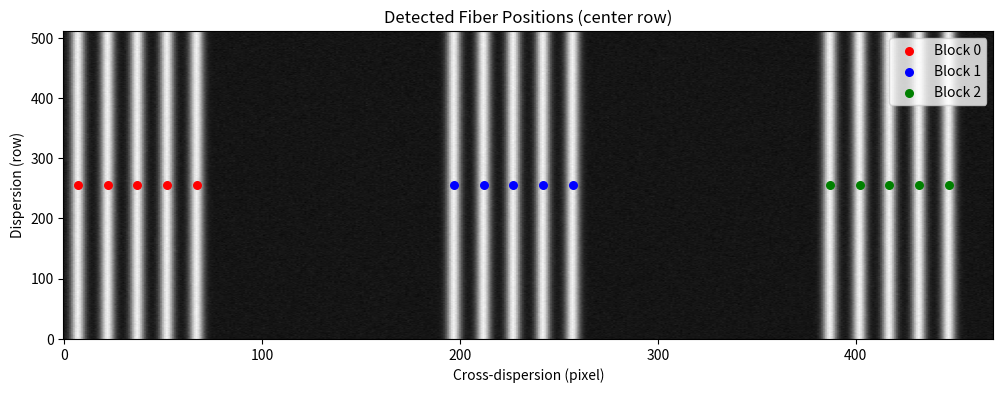

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(image, aspect='auto', origin='lower', cmap='gray')

colors = ['red', 'blue', 'green']
for bid in np.unique(fibermap['BLOCKID']):
    block = fibermap.get_block(bid)
    ax.scatter(
        block['APPROX_X'],
        np.full(len(block), 256),
        c=colors[bid],
        s=30,
        label=f'Block {bid}',
        zorder=5,
    )

ax.set_xlabel('Cross-dispersion (pixel)')
ax.set_ylabel('Dispersion (row)')
ax.set_title('Detected Fiber Positions (center row)')
ax.legend()
plt.show()

## 4. Trace Fibers and Fit Polynomials

`TraceMask` traces the barycenter of each fiber upward and downward from the center row,
then fits a Legendre polynomial to the trace.

In [6]:
%%time
tracemask = TraceMask.from_fibermap(
    fibermap=fibermap,
    image=image,
    poly_deg=3,
)

print(f"TraceMask: {tracemask.n_fibers} fibers, polynomial degree {tracemask.coeffs.shape[1]-1}")

TraceMask: 15 fibers, polynomial degree 3
CPU times: user 5.45 s, sys: 308 ms, total: 5.75 s
Wall time: 6.02 s


## 5. Visualize Traces

Evaluate the polynomial model at all rows and overlay on the image.

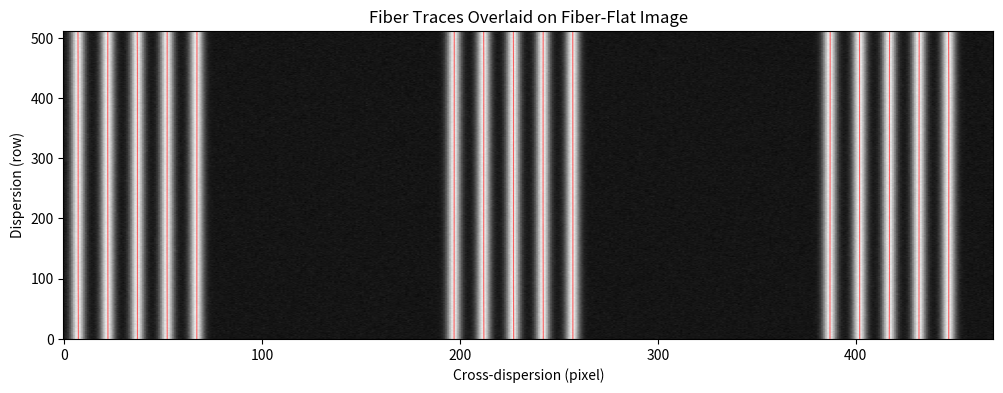

In [7]:
rows = np.arange(image.shape[0])
positions = tracemask.eval(rows)

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(image, aspect='auto', origin='lower', cmap='gray')

for i in range(tracemask.n_fibers):
    ax.plot(positions[i, :], rows, 'r-', alpha=0.6, lw=0.8)

ax.set_xlabel('Cross-dispersion (pixel)')
ax.set_ylabel('Dispersion (row)')
ax.set_title('Fiber Traces Overlaid on Fiber-Flat Image')
plt.show()

## 6. Validate Trace Accuracy

For straight synthetic fibers, the trace at the center row should match the detected `APPROX_X`.

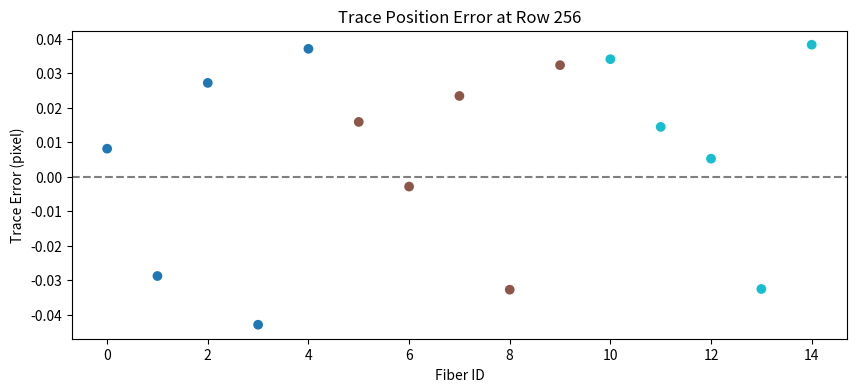

RMS error: 0.028 pixels
Max error: 0.043 pixels


In [8]:
center_row = 256
center_positions = positions[:, center_row]
errors = center_positions - fibermap['APPROX_X']

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(fibermap['FIBERID'], errors, c=fibermap['BLOCKID'], cmap='tab10')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Fiber ID')
ax.set_ylabel('Trace Error (pixel)')
ax.set_title(f'Trace Position Error at Row {center_row}')
plt.show()

print(f"RMS error: {np.sqrt(np.mean(errors**2)):.3f} pixels")
print(f"Max error: {np.max(np.abs(errors)):.3f} pixels")

## Summary

This pipeline separates **identification** (`FibersIdentifier` → `FiberMap`) from **tracing** (`TraceMask`).

Key benefits:
- **Clean data model**: `FiberMap` is a structured `astropy.Table`, not a list of dicts.
- **Memory efficient**: `TraceMask` stores polynomial coefficients, not dense 2-D arrays.
- **Testable**: Each class has a single responsibility and can be tested independently.
- **Extensible**: You can swap the tracing algorithm (e.g., cross-correlation instead of barycenter) without touching identification.